In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv(r"C:\Calibo\Unsupervised_learning\Supervised_Learning_Messy_Customer_Churn.csv")
df.shape

(184, 13)

In [3]:
df.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


In [4]:
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months',
       'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB',
       'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region',
       'Plan_Type', 'Churn'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            184 non-null    str    
 1   Age                    176 non-null    float64
 2   Annual_Income          173 non-null    str    
 3   Tenure_Months          177 non-null    float64
 4   Monthly_Charges        178 non-null    float64
 5   Support_Calls_Last_3M  179 non-null    float64
 6   Data_Usage_GB          178 non-null    float64
 7   Satisfaction_Score     178 non-null    float64
 8   Contract_Type          184 non-null    str    
 9   Payment_Method         184 non-null    str    
 10  Region                 184 non-null    str    
 11  Plan_Type              184 non-null    str    
 12  Churn                  184 non-null    str    
dtypes: float64(6), str(7)
memory usage: 27.0 KB


In [6]:
df['Annual_Income'] = pd.to_numeric(df['Annual_Income'], errors='coerce')

In [7]:
df['Annual_Income'].dtype

dtype('float64')

In [8]:
df.describe()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
count,176.000000,1.720000e+02,177.000000,178.000000,179.000000,178.000000,178.000000
mean,36.164773,1.218552e+05,39.395480,80.205899,3.217877,17.806180,5.803371
std,12.865951,7.579821e+05,21.545185,74.179370,2.577455,9.245516,2.947869
min,-5.000000,-1.200000e+04,1.000000,0.000000,0.000000,-10.000000,1.000000
25%,29.000000,4.860000e+04,25.000000,57.885000,2.000000,11.600000,4.000000
50%,36.000000,6.440000e+04,38.000000,73.565000,3.000000,18.200000,6.000000
75%,41.000000,7.797500e+04,55.000000,90.280000,4.000000,24.200000,8.000000
max,145.000000,9.999999e+06,150.000000,999.000000,30.000000,44.000000,15.000000


In [9]:
df["Churn"].value_counts()

Churn
Yes    97
No     87
Name: count, dtype: int64

In [10]:
df["Customer_ID"].value_counts()

Customer_ID
CUST-1043    2
CUST-1110    2
CUST-1008    2
CUST-1152    2
CUST-1020    1
            ..
CUST-1107    1
CUST-1015    1
CUST-1093    1
CUST-1180    1
CUST-1103    1
Name: count, Length: 180, dtype: int64

In [11]:
df.isnull().sum()

Customer_ID               0
Age                       8
Annual_Income            12
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             0
Payment_Method            0
Region                    0
Plan_Type                 0
Churn                     0
dtype: int64

In [12]:
df.isnull().sum().sum()

np.int64(50)

In [13]:
df.duplicated().sum()

np.int64(4)

In [14]:
df['Customer_ID'].duplicated().sum()

np.int64(4)

In [15]:
df[df.duplicated(keep=False)].sort_values('Customer_ID').head(10)

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
132,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
154,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
119,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
46,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
71,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
169,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No
176,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No


In [16]:
numeric_cols = ['Age','Annual_Income','Tenure_Months','Monthly_Charges',
                'Support_Calls_Last_3M','Data_Usage_GB','Satisfaction_Score']

In [17]:
num_cols = df.select_dtypes(exclude=['object']).columns
print(num_cols)

Index(['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges',
       'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score'],
      dtype='str')


In [18]:
object_cols = df.select_dtypes(include=['object']).columns
print(object_cols)

Index(['Customer_ID', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type',
       'Churn'],
      dtype='str')


C:\Users\KEERTHI\AppData\Local\Temp\ipykernel_26240\1744700887.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include=['object']).columns


In [19]:
df["Contract_Type"].value_counts()

Contract_Type
Monthly    104
1 Year      52
2 Year      23
MONTHLY      1
2-Year       1
1 year       1
monthly      1
?            1
Name: count, dtype: int64

In [20]:
df['Contract_Type'] = df['Contract_Type'].replace('?', pd.NA)

df['Contract_Type'] = (
    df['Contract_Type']
    .str.strip()
    .str.lower()
    .replace({
        'monthly': 'Monthly',
        '1 year': '1 Year',
        '2 year': '2 Year',
        '2-year': '2 Year'
    })
)
df["Contract_Type"].value_counts()

Contract_Type
Monthly    106
1 Year      53
2 Year      24
Name: count, dtype: int64

In [21]:
df['Contract_Type'] = df['Contract_Type'].fillna(df['Contract_Type'].mode()[0])

In [22]:
df["Payment_Method"].value_counts()

Payment_Method
Bank Transfer    48
UPI              46
Credit Card      43
Debit Card       42
?                 1
bank transfer     1
upi               1
Unknown           1
Credit card       1
Name: count, dtype: int64

In [23]:
df["Payment_Method"] = df["Payment_Method"].str.strip().str.title()
df["Payment_Method"].value_counts()


Payment_Method
Bank Transfer    49
Upi              47
Credit Card      44
Debit Card       42
?                 1
Unknown           1
Name: count, dtype: int64

In [24]:
df["Payment_Method"] = df["Payment_Method"].replace("?", np.nan)

In [25]:
df["Payment_Method"] = df["Payment_Method"].fillna(df["Payment_Method"].mode()[0])

In [26]:
df["Payment_Method"].value_counts()

Payment_Method
Bank Transfer    50
Upi              47
Credit Card      44
Debit Card       42
Unknown           1
Name: count, dtype: int64

In [27]:
df["Region"].value_counts()

Region
South     50
North     49
West      47
East      34
west       1
NORTH      1
?          1
south      1
Name: count, dtype: int64

In [28]:
df["Region"] = df["Region"].str.strip().str.title()
df["Region"].value_counts()

Region
South    51
North    50
West     48
East     34
?         1
Name: count, dtype: int64

In [29]:
df["Region"] = df["Region"].replace("?", np.nan)

In [30]:
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])

In [31]:
df["Region"].value_counts()

Region
South    52
North    50
West     48
East     34
Name: count, dtype: int64

In [32]:
df["Plan_Type"].value_counts()

Plan_Type
Standard     93
Basic        48
Premium      40
basic         1
premium       1
STANDARD      1
Name: count, dtype: int64

In [33]:
df["Plan_Type"] = df["Plan_Type"].str.strip().str.title()
df["Plan_Type"].value_counts()

Plan_Type
Standard    94
Basic       49
Premium     41
Name: count, dtype: int64

In [34]:
negative_count = (df.select_dtypes(include='number') < 0).sum()
print(negative_count)

Age                      1
Annual_Income            2
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            7
Satisfaction_Score       0
dtype: int64


In [35]:
numeric_cols = df.select_dtypes(include="number")
negative_rows = df[(numeric_cols < 0).any(axis=1)]
negative_rows

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
6,CUST-1025,31.0,88000.0,37.0,88.42,4.0,-2.1,9.0,1 Year,Debit Card,South,Standard,No
45,CUST-1105,34.0,35800.0,60.0,118.63,3.0,-0.8,7.0,2 Year,Upi,East,Standard,No
63,CUST-1079,NaN,53100.0,29.0,83.71,3.0,-1.6,5.0,Monthly,Upi,North,Basic,Yes
77,CUST-1033,36.0,57800.0,72.0,50.61,3.0,-1.1,1.0,Monthly,Credit Card,North,Standard,Yes
95,CUST-1143,20.0,-11500.0,2.0,57.34,NaN,19.4,2.0,1 Year,Credit Card,West,Standard,No
112,CUST-1062,34.0,-12000.0,29.0,60.69,4.0,18.9,4.0,Monthly,Upi,East,Basic,Yes
120,CUST-1124,22.0,50100.0,57.0,93.56,3.0,-0.3,9.0,Monthly,Upi,South,Standard,No
144,CUST-1018,-5.0,75900.0,64.0,137.15,5.0,14.2,5.0,Monthly,Upi,North,Premium,Yes
177,CUST-1021,51.0,100400.0,14.0,51.52,2.0,-2.0,1.0,2 Year,Upi,South,Premium,No
178,CUST-1072,51.0,NaN,38.0,77.19,5.0,-10.0,5.0,Monthly,Credit Card,West,Standard,No


In [36]:
df["Age"] = df["Age"].mask(df["Age"] < 0, np.nan)
df["Data_Usage_GB"] = df["Data_Usage_GB"].mask(
    df["Data_Usage_GB"] < 0, np.nan
)

In [37]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Data_Usage_GB"] = df["Data_Usage_GB"].fillna(
    df["Data_Usage_GB"].median()
)

In [38]:
negative_count = (df.select_dtypes(include='number') < 0).sum()
print(negative_count)

Age                      0
Annual_Income            2
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
dtype: int64


In [39]:
median_income = df.loc[df['Annual_Income'] >= 0, 'Annual_Income'].median()
df.loc[df['Annual_Income'] < 0, 'Annual_Income'] = median_income
print("Negative values:", (df['Annual_Income'] < 0).sum())
print("Median used:", median_income)

Negative values: 0
Median used: 64700.0


In [40]:
numeric_df = df.select_dtypes(include="number")
correlation = numeric_df.corr()
correlation

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Age,1.000000,0.005074,0.032331,0.005018,-0.021513,-0.029712,-0.051955
Annual_Income,0.005074,1.000000,-0.127055,0.011238,0.025034,-0.120125,0.087546
Tenure_Months,0.032331,-0.127055,1.000000,-0.006854,-0.040394,0.034958,0.005583
Monthly_Charges,0.005018,0.011238,-0.006854,1.000000,0.021635,0.001403,0.105330
Support_Calls_Last_3M,-0.021513,0.025034,-0.040394,0.021635,1.000000,-0.036642,-0.031787
Data_Usage_GB,-0.029712,-0.120125,0.034958,0.001403,-0.036642,1.000000,0.042551
Satisfaction_Score,-0.051955,0.087546,0.005583,0.105330,-0.031787,0.042551,1.000000


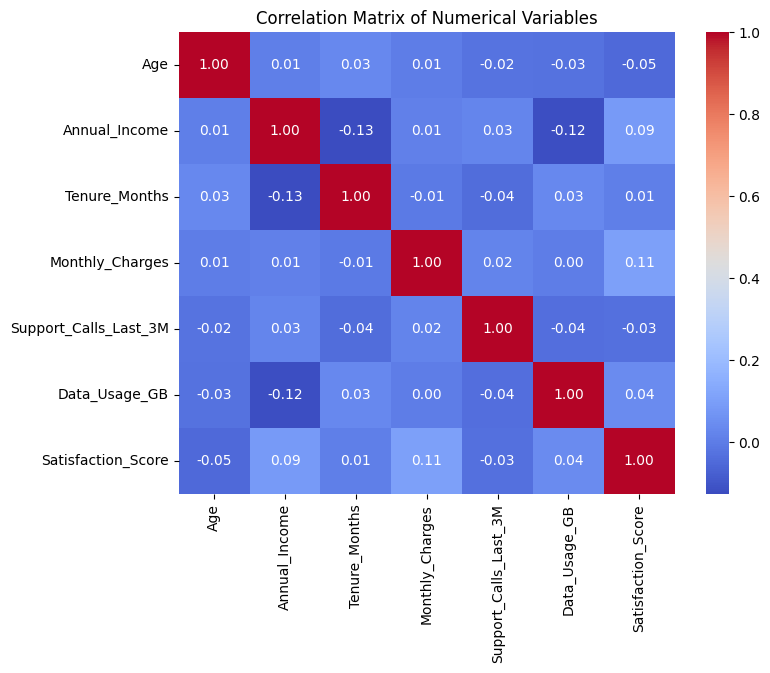

In [41]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [42]:
numeric_cols = df.select_dtypes(include="number")
for col in numeric_cols.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n{col}")
    print(f"Lower limit: {lower}")
    print(f"Upper limit: {upper}")
    print(f"Number of outliers: {len(outliers)}")


Age
Lower limit: 13.5
Upper limit: 57.5
Number of outliers: 5

Annual_Income
Lower limit: 6912.5
Upper limit: 120612.5
Number of outliers: 2

Tenure_Months
Lower limit: -20.0
Upper limit: 100.0
Number of outliers: 1

Monthly_Charges
Lower limit: 9.292500000000011
Upper limit: 138.8725
Number of outliers: 4

Support_Calls_Last_3M
Lower limit: -1.0
Upper limit: 7.0
Number of outliers: 1

Data_Usage_GB
Lower limit: -3.3125000000000036
Upper limit: 40.587500000000006
Number of outliers: 2

Satisfaction_Score
Lower limit: -2.0
Upper limit: 14.0
Number of outliers: 1


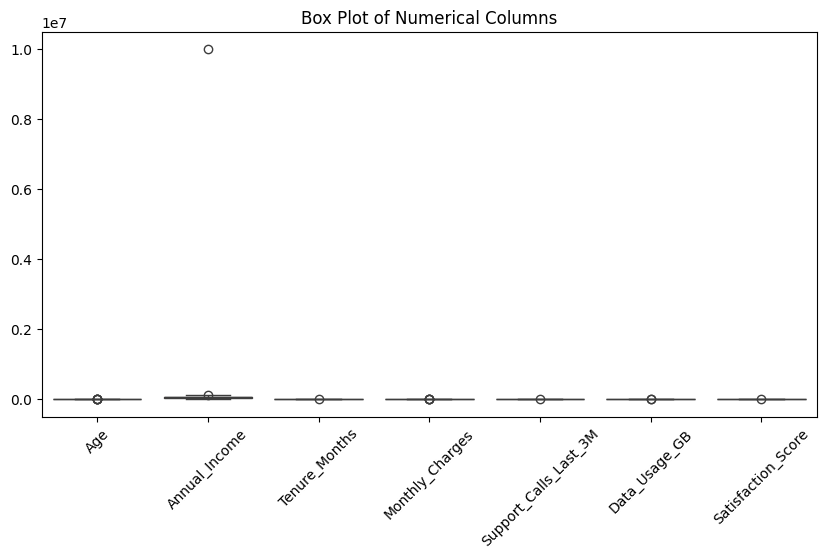

In [43]:
numeric_cols = df.select_dtypes(include="number")
plt.figure(figsize=(10, 5))
sns.boxplot(data=numeric_cols)
plt.xticks(rotation=45)
plt.title("Box Plot of Numerical Columns")
plt.show()

In [44]:
numeric_cols = df.select_dtypes(include="number").columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    percentage = (outlier_count / len(df)) * 100
    print(f"{col}: {outlier_count} outliers ({percentage:.2f}%)")

Age: 5 outliers (2.72%)
Annual_Income: 2 outliers (1.09%)
Tenure_Months: 1 outliers (0.54%)
Monthly_Charges: 4 outliers (2.17%)
Support_Calls_Last_3M: 1 outliers (0.54%)
Data_Usage_GB: 2 outliers (1.09%)
Satisfaction_Score: 1 outliers (0.54%)


In [45]:
numeric_cols = df.select_dtypes(include="number").columns
total_outliers = 0
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    total_outliers += ((df[col] < lower) | (df[col] > upper)).sum()
print("Total outliers:", total_outliers)

Total outliers: 16


In [46]:
total_values = len(df) * len(numeric_cols)
percentage = (total_outliers / total_values) * 100
print(f"Total outliers: {total_outliers}")
print(f"Outlier percentage: {percentage:.2f}%")

Total outliers: 16
Outlier percentage: 1.24%


In [47]:

numeric_columns = [
    'Age',
    'Annual_Income',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

# Replace invalid values with NaN
df['Age'] = df['Age'].replace([10, 16, 17, 145], pd.NA)

df['Annual_Income'] = df['Annual_Income'].replace([9999999], pd.NA)

df['Tenure_Months'] = df['Tenure_Months'].replace([150], pd.NA)

df['Monthly_Charges'] = df['Monthly_Charges'].replace([0, 999], pd.NA)

df['Support_Calls_Last_3M'] = df['Support_Calls_Last_3M'].replace([30], pd.NA)

df['Satisfaction_Score'] = df['Satisfaction_Score'].replace([15], pd.NA)

# Convert to numeric
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Replace invalid/missing values with column median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fix capitalization
if 'Payment_Method' in df.columns:
    df['Payment_Method'] = df['Payment_Method'].replace({
        'Upi': 'UPI'
    })

print(df.head())

  Customer_ID   Age  Annual_Income  Tenure_Months  Monthly_Charges  \
0   CUST-1020  22.0        23800.0           11.0            62.96   
1   CUST-1043  35.0        69400.0           17.0            75.63   
2   CUST-1157  55.0        64700.0           49.0            92.85   
3   CUST-1112  36.0        80000.0            9.0            85.67   
4   CUST-1149  41.0        95700.0           51.0            60.77   

   Support_Calls_Last_3M  Data_Usage_GB  Satisfaction_Score Contract_Type  \
0                    7.0           20.4                 5.0       Monthly   
1                    6.0           17.5                 9.0       Monthly   
2                    3.0           21.6                 1.0       Monthly   
3                    0.0           34.3                 9.0       Monthly   
4                    1.0           23.7                 9.0       Monthly   

  Payment_Method Region Plan_Type Churn  
0  Bank Transfer  North  Standard   Yes  
1  Bank Transfer  South     Basi

In [48]:
numeric_columns = [
    'Age',
    'Annual_Income',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

total_outliers = 0
total_values = 0

for col in numeric_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    
    outlier_count = len(outliers)
    
    total_outliers += outlier_count
    total_values += df[col].count()
    
    print(f"{col}: {outlier_count} outliers")


outlier_percentage = (total_outliers / total_values) * 100

print("\nTotal Outlier Values:", total_outliers)
print("Total Numerical Values:", total_values)
print(f"Overall Outlier Percentage: {outlier_percentage:.2f}%")

Age: 3 outliers
Annual_Income: 3 outliers
Tenure_Months: 0 outliers
Monthly_Charges: 8 outliers
Support_Calls_Last_3M: 0 outliers
Data_Usage_GB: 2 outliers
Satisfaction_Score: 0 outliers

Total Outlier Values: 16
Total Numerical Values: 1288
Overall Outlier Percentage: 1.24%


In [49]:
df.isnull().sum()

Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64

In [50]:
df = df.drop_duplicates()

In [51]:
df.shape

(180, 13)

In [52]:
numeric_cols = df.select_dtypes(include="number").columns
print(df[numeric_cols].median())

Age                         36.000
Annual_Income            64700.000
Tenure_Months               38.000
Monthly_Charges             73.565
Support_Calls_Last_3M        3.000
Data_Usage_GB               18.800
Satisfaction_Score           6.000
dtype: float64


In [53]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [54]:
print(df[numeric_cols].isnull().sum())
print(df[numeric_cols].dtypes)

Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
dtype: int64
Age                      float64
Annual_Income            float64
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
dtype: object


In [55]:
import pandas as pd
import numpy as np

# ==========================================
# 1. BASIC DATASET INFORMATION
# ==========================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Rows and Columns:", df.shape)
print("\nData Types:")
print(df.dtypes)


# ==========================================
# 2. NULL VALUES
# ==========================================

print("\n" + "=" * 60)
print("NULL VALUES")
print("=" * 60)

null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]

if len(null_counts) == 0:
    print("No null values found.")
else:
    print(null_counts)
    print("\nTotal null values:", df.isnull().sum().sum())


# ==========================================
# 3. DUPLICATE DATA
# ==========================================

print("\n" + "=" * 60)
print("DUPLICATE DATA")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate rows:")
    display(df[df.duplicated(keep=False)])

# ==========================================
# 5. INVALID / NON-NUMERIC DATA
# ==========================================

print("\n" + "=" * 60)
print("INVALID / NON-NUMERIC DATA")
print("=" * 60)

for col in numeric_cols:
    invalid = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()
    
    if invalid.sum() > 0:
        print(f"\n{col}: {invalid.sum()} invalid values")
        print(df.loc[invalid, col].unique())

print("\nObject/Categorical columns:")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"{col}: {df[col].isna().sum()} null values")


# ==========================================
# 6. VALUE COUNT OF CATEGORICAL DATA
# ==========================================

print("\n" + "=" * 60)
print("CATEGORICAL VALUE COUNTS")
print("=" * 60)

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


# ==========================================
# 7. SUMMARY
# ==========================================

print("\n" + "=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)

print("Total Rows:", len(df))
print("Total Columns:", len(df.columns))
print("Total Null Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())
print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

DATASET INFORMATION
Rows and Columns: (180, 13)

Data Types:
Customer_ID                  str
Age                      float64
Annual_Income            float64
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type                str
Payment_Method               str
Region                       str
Plan_Type                    str
Churn                        str
dtype: object

NULL VALUES
No null values found.

DUPLICATE DATA
Duplicate rows: 0

INVALID / NON-NUMERIC DATA

Object/Categorical columns:
Customer_ID: 0 null values
Contract_Type: 0 null values
Payment_Method: 0 null values
Region: 0 null values
Plan_Type: 0 null values
Churn: 0 null values

CATEGORICAL VALUE COUNTS

--- Customer_ID ---
Customer_ID
CUST-1020    1
CUST-1043    1
CUST-1157    1
CUST-1112    1
CUST-1149    1
            ..
CUST-1107    1
CUST-1015    1
CUST-1093    1
CUST-1180    1
CUST-11

C:\Users\KEERTHI\AppData\Local\Temp\ipykernel_26240\2039922168.py:67: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


In [56]:
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical Columns:", len(categorical_cols))
print(categorical_cols.tolist())

Categorical Columns: 6
['Customer_ID', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']


C:\Users\KEERTHI\AppData\Local\Temp\ipykernel_26240\416024578.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [57]:
cols = ['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']
for col in cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Contract_Type ---
Contract_Type
Monthly    104
1 Year      52
2 Year      24
Name: count, dtype: int64

--- Payment_Method ---
Payment_Method
Bank Transfer    47
UPI              47
Credit Card      44
Debit Card       41
Unknown           1
Name: count, dtype: int64

--- Region ---
Region
North    50
South    50
West     46
East     34
Name: count, dtype: int64

--- Plan_Type ---
Plan_Type
Standard    94
Basic       47
Premium     39
Name: count, dtype: int64


In [58]:
numeric_cols = df.select_dtypes(include=np.number).columns
negative_counts = {}
for col in numeric_cols:
    count = (df[col] < 0).sum()
    if count > 0:
        negative_counts[col] = count

if len(negative_counts) == 0:
    print("No negative values found.")
else:
    print("Negative values by column:")
    for col, count in negative_counts.items():
        print(f"{col}: {count}")

No negative values found.


In [59]:
clean_df = df.copy()

In [60]:
print(clean_df.shape)
print(clean_df.isnull().sum())
print(clean_df.duplicated().sum())

(180, 13)
Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64
0


In [61]:
print((clean_df.select_dtypes(include='number') < 0).sum())

Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
dtype: int64


In [62]:
clean_df.to_csv("cleaned_customer1.csv", index=False)

### Data preprocessing(unsupervised)

In [63]:
df_cluster = df.drop(columns=["Churn", "Customer_ID"])
df_cluster.head()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard
1,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic
2,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic
3,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard
4,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium


In [64]:
numeric_columns = df_cluster.select_dtypes(include=["int", "float"]).columns.tolist()
categorical_columns = df_cluster.select_dtypes(include=["object"]).columns.tolist()
numeric_columns

C:\Users\KEERTHI\AppData\Local\Temp\ipykernel_26240\2298182977.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_cluster.select_dtypes(include=["object"]).columns.tolist()


['Age',
 'Annual_Income',
 'Tenure_Months',
 'Monthly_Charges',
 'Support_Calls_Last_3M',
 'Data_Usage_GB',
 'Satisfaction_Score']

In [65]:
correlation = df[numeric_columns].corr()

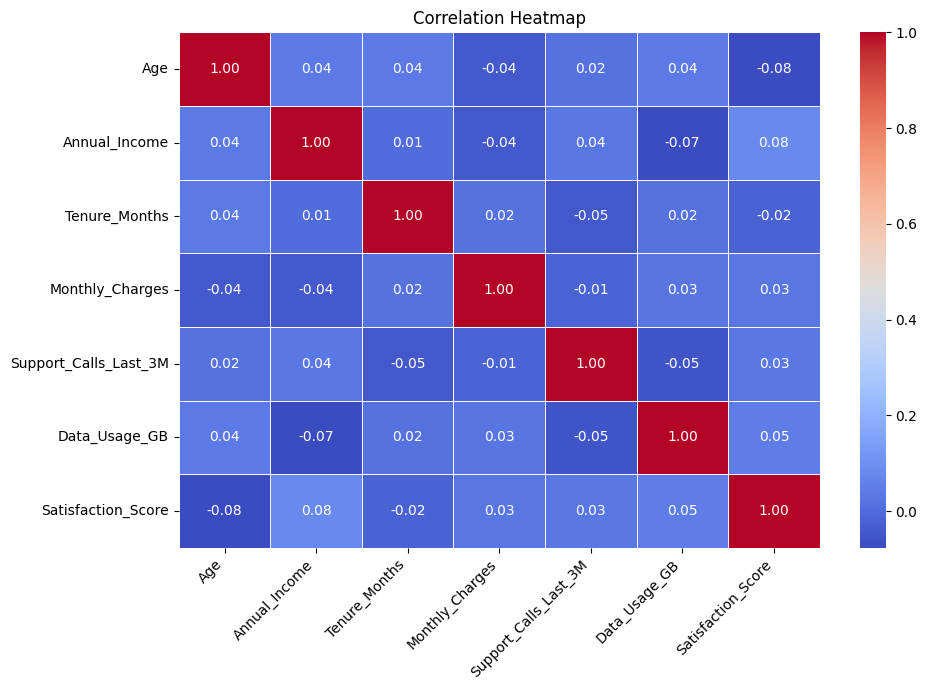

In [66]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

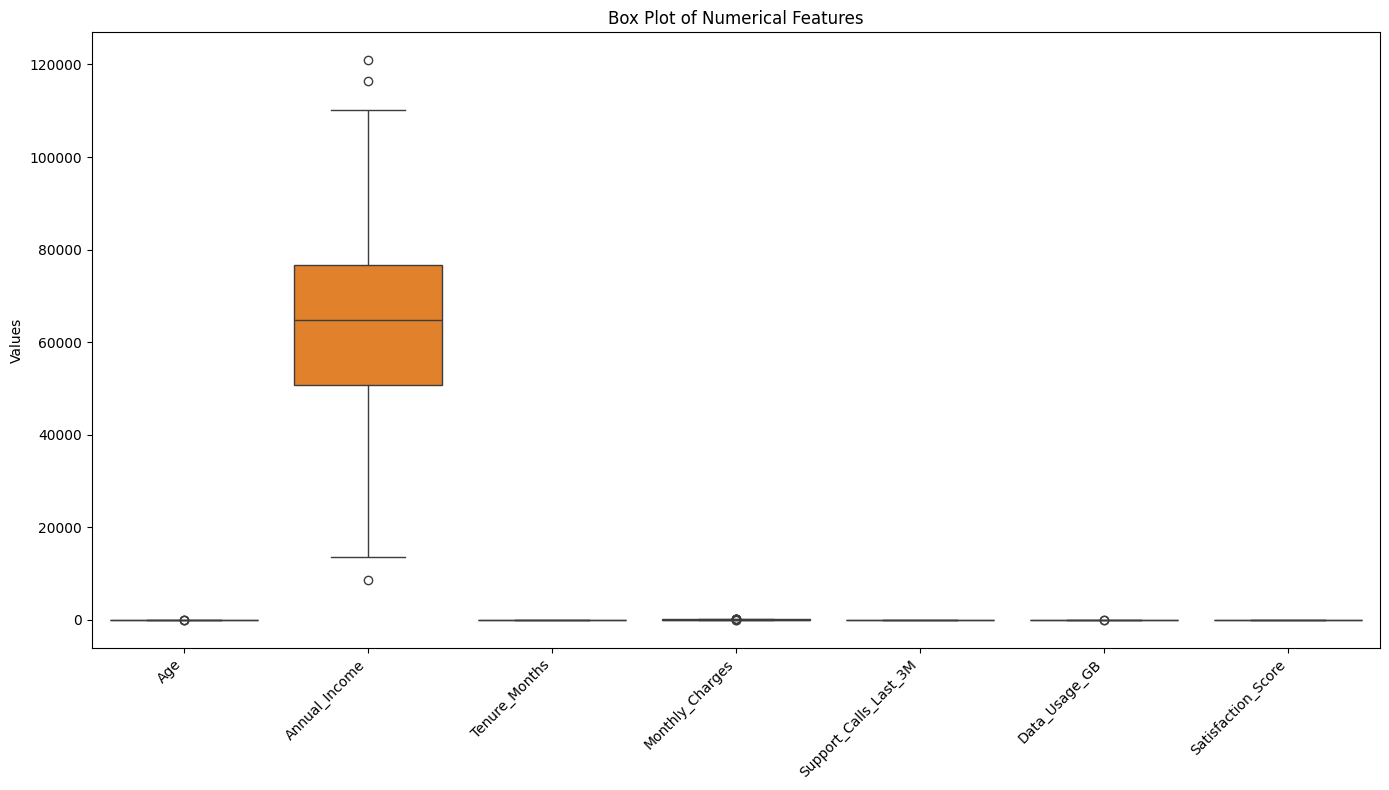

In [67]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df[numeric_columns])
plt.title('Box Plot of Numerical Features')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

In [68]:
df_cluster[numeric_columns] = df_cluster[numeric_columns].fillna(
    df_cluster[numeric_columns].median()
)

for column in categorical_columns:
    df_cluster[column] = df_cluster[column].fillna(
        df_cluster[column].mode()[0]
    )
df_cluster.isnull().sum()

Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
dtype: int64

### Convert Categorical Features to Numerical Features

Clustering algorithms require numerical input, so categorical variables are converted using one-hot encoding.

In [69]:
df_encoded = pd.get_dummies(
    df_cluster,
    columns=categorical_columns,
    drop_first=False,
    dtype=int
)
df_encoded

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type_1 Year,Contract_Type_2 Year,Contract_Type_Monthly,...,Payment_Method_Debit Card,Payment_Method_UPI,Payment_Method_Unknown,Region_East,Region_North,Region_South,Region_West,Plan_Type_Basic,Plan_Type_Premium,Plan_Type_Standard
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,0,0,1,...,0,0,0,0,0,1,0,1,0,0
2,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,0,0,1,...,0,1,0,0,0,0,1,1,0,0
3,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,0,0,1,...,0,1,0,0,0,1,0,0,0,1
4,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,0,0,1,...,1,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,55.0,54100.0,68.0,99.59,6.0,21.5,8.0,1,0,0,...,0,0,0,1,0,0,0,1,0,0
180,19.0,63000.0,38.0,64.24,1.0,13.0,7.0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
181,29.0,45300.0,69.0,67.48,1.0,10.6,6.0,0,0,1,...,1,0,0,1,0,0,0,0,0,1
182,63.0,47100.0,45.0,65.58,0.0,11.3,1.0,0,0,1,...,0,1,0,1,0,0,0,0,0,1


In [70]:
df_encoded.shape

(180, 22)

### Select Features for Clustering

In [71]:
X = df_encoded.copy()
X.shape

(180, 22)

In [72]:
X.columns

Index(['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges',
       'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score',
       'Contract_Type_1 Year', 'Contract_Type_2 Year', 'Contract_Type_Monthly',
       'Payment_Method_Bank Transfer', 'Payment_Method_Credit Card',
       'Payment_Method_Debit Card', 'Payment_Method_UPI',
       'Payment_Method_Unknown', 'Region_East', 'Region_North', 'Region_South',
       'Region_West', 'Plan_Type_Basic', 'Plan_Type_Premium',
       'Plan_Type_Standard'],
      dtype='str')

### Feature Scaling

In [73]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.67622814, -1.91652452, -1.43010681, ..., -0.59446065,
        -0.52592371,  0.95650071],
       [-0.15356748,  0.19502507, -1.1195266 , ...,  1.68219714,
        -0.52592371, -1.04547753],
       [ 2.18898736, -0.02261272,  0.53690115, ...,  1.68219714,
        -0.52592371, -1.04547753],
       ...,
       [-0.85633394, -0.92094741,  1.57216849, ..., -0.59446065,
        -0.52592371,  0.95650071],
       [ 3.1260093 , -0.83759677,  0.32984768, ..., -0.59446065,
        -0.52592371,  0.95650071],
       [-0.03643974, -0.78202968, -1.32658007, ..., -0.59446065,
        -0.52592371,  0.95650071]], shape=(180, 22))

K-means Clustering

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [75]:
print("Shape of scaled data:", X_scaled.shape)
print("Number of customer records:", X_scaled.shape[0])
print("Number of features:", X_scaled.shape[1])

Shape of scaled data: (180, 22)
Number of customer records: 180
Number of features: 22


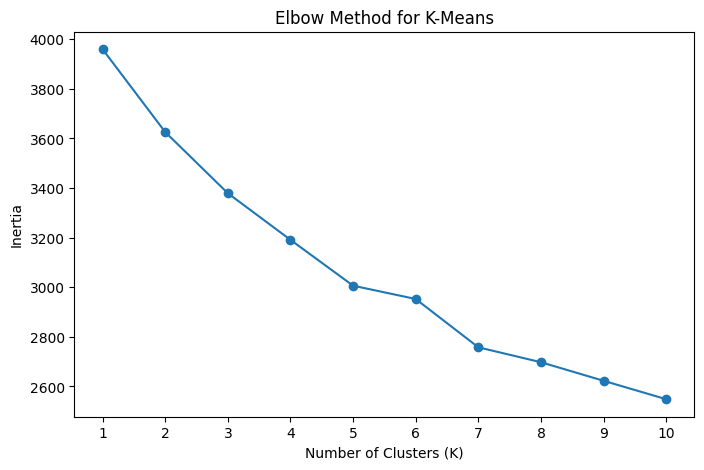

In [76]:
inertia_values = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_values, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(range(1, 11))
plt.show()

In [77]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

print("K-Means clustering completed.")

K-Means clustering completed.


In [78]:
print("Number of customers in each cluster:")

print(
    df["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

Number of customers in each cluster:
KMeans_Cluster
0    39
1    51
2    45
3    44
4     1
Name: count, dtype: int64


In [79]:
score = silhouette_score(X_scaled, kmeans_labels)

print("Silhouette Score:", score)

Silhouette Score: 0.08975768265387586


In [80]:
silhouette_scores = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print("K =", k, "| Silhouette Score =", round(score, 4))

K = 2 | Silhouette Score = 0.0863
K = 3 | Silhouette Score = 0.1062
K = 4 | Silhouette Score = 0.0989
K = 5 | Silhouette Score = 0.0898
K = 6 | Silhouette Score = 0.0949
K = 7 | Silhouette Score = 0.0843
K = 8 | Silhouette Score = 0.095
K = 9 | Silhouette Score = 0.0828
K = 10 | Silhouette Score = 0.0898


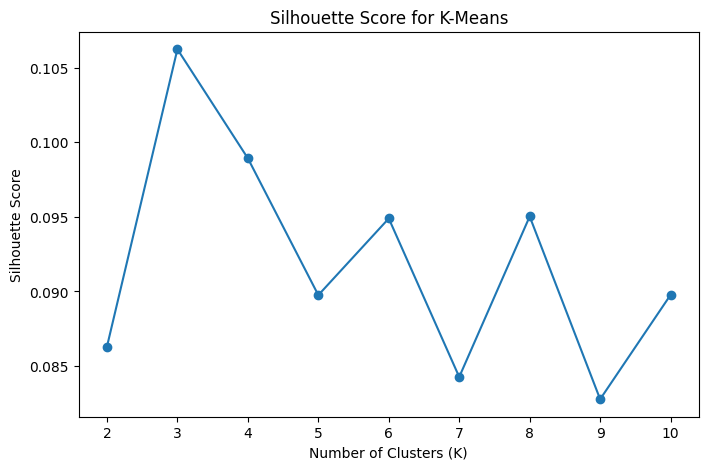

In [81]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")
plt.xticks(range(2, 11))
plt.show()

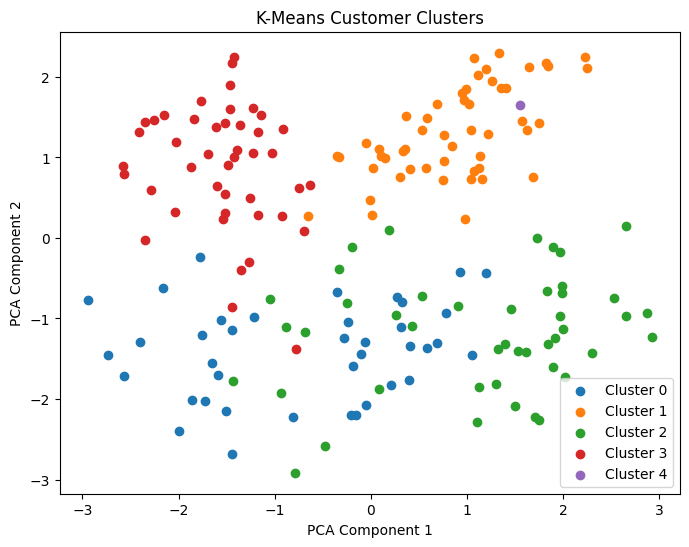

In [82]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

kmeans_pca_df = pd.DataFrame({
    "PCA_1": X_pca[:, 0],
    "PCA_2": X_pca[:, 1],
    "KMeans_Cluster": kmeans_labels
})

plt.figure(figsize=(8, 6))

for cluster in sorted(kmeans_pca_df["KMeans_Cluster"].unique()):
    cluster_data = kmeans_pca_df[
        kmeans_pca_df["KMeans_Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PCA_1"],
        cluster_data["PCA_2"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Customer Clusters")
plt.legend()
plt.show()

In [83]:
numerical_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

cluster_summary = df.groupby("KMeans_Cluster")[
    numerical_columns
].mean().round(2)

cluster_summary

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
KMeans_Cluster,,,,,,,
0,35.41,68425.64,38.87,80.78,2.87,15.85,6.05
1,36.53,63362.75,40.78,68.46,3.22,19.36,6.10
2,37.96,61695.56,38.20,77.57,3.18,21.48,5.02
3,35.30,67054.55,36.36,75.04,2.93,17.44,5.80
4,31.00,107100.00,38.00,55.24,2.00,20.60,9.00


In [84]:
categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

for column in categorical_columns:
    print("\n", column, "by K-Means Cluster")

    print(
        pd.crosstab(
            df["KMeans_Cluster"],
            df[column],
            normalize="index"
        ).round(2)
    )


 Contract_Type by K-Means Cluster
Contract_Type   1 Year  2 Year  Monthly
KMeans_Cluster                         
0                 0.26    0.21     0.54
1                 0.00    0.00     1.00
2                 0.24    0.07     0.69
3                 0.70    0.30     0.00
4                 0.00    0.00     1.00

 Payment_Method by K-Means Cluster
Payment_Method  Bank Transfer  Credit Card  Debit Card   UPI  Unknown
KMeans_Cluster                                                       
0                        0.21         0.26        0.28  0.26      0.0
1                        0.27         0.33        0.10  0.29      0.0
2                        0.31         0.20        0.31  0.18      0.0
3                        0.25         0.18        0.25  0.32      0.0
4                        0.00         0.00        0.00  0.00      1.0

 Region by K-Means Cluster
Region          East  North  South  West
KMeans_Cluster                          
0               0.26   0.26   0.21  0.28
1       

### Hierarchical Clustering

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [86]:
print("Shape of scaled data:", X_scaled.shape)
print("Number of customer records:", X_scaled.shape[0])
print("Number of features:", X_scaled.shape[1])

Shape of scaled data: (180, 22)
Number of customer records: 180
Number of features: 22


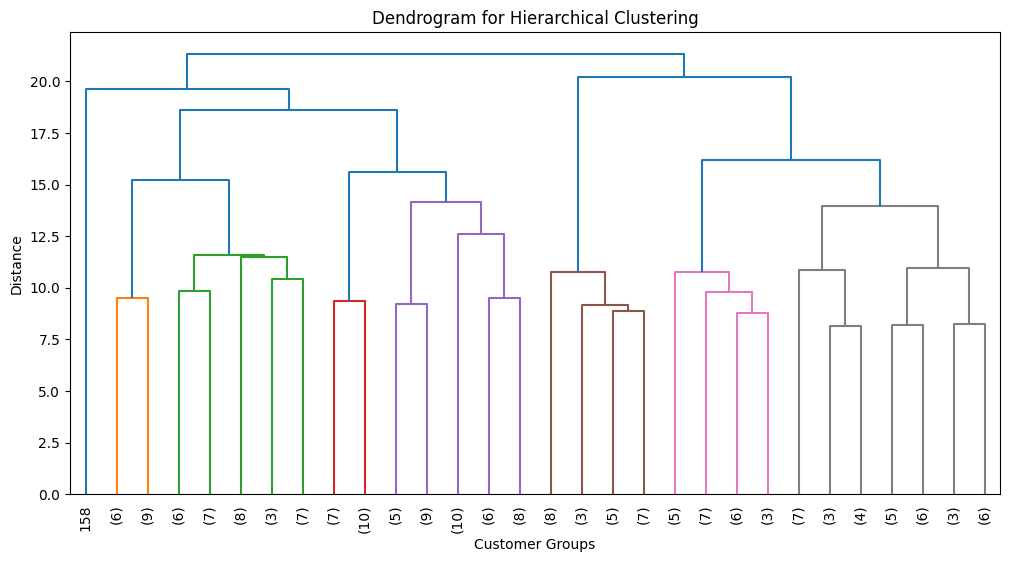

In [87]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Customer Groups")
plt.ylabel("Distance")
plt.show()

In [88]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

df["Hierarchical_Cluster"] = hierarchical_labels

print("Hierarchical clustering completed.")

Hierarchical clustering completed.


In [89]:
print("Number of customers in each cluster:")

print(
    df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

Number of customers in each cluster:
Hierarchical_Cluster
0    55
1    55
2    23
3     1
4    46
Name: count, dtype: int64


In [90]:
hierarchical_score = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print("Hierarchical Clustering Silhouette Score:",
      round(hierarchical_score, 4))

Hierarchical Clustering Silhouette Score: 0.0687


In [91]:
hierarchical_silhouette_scores = []

for k in range(2, 11):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    hierarchical_silhouette_scores.append(score)

    print(
        "K =", k,
        "| Silhouette Score =", round(score, 4)
    )

K = 2 | Silhouette Score = 0.0589
K = 3 | Silhouette Score = 0.0722
K = 4 | Silhouette Score = 0.0755
K = 5 | Silhouette Score = 0.0687
K = 6 | Silhouette Score = 0.0675
K = 7 | Silhouette Score = 0.053
K = 8 | Silhouette Score = 0.0633
K = 9 | Silhouette Score = 0.0648
K = 10 | Silhouette Score = 0.0729


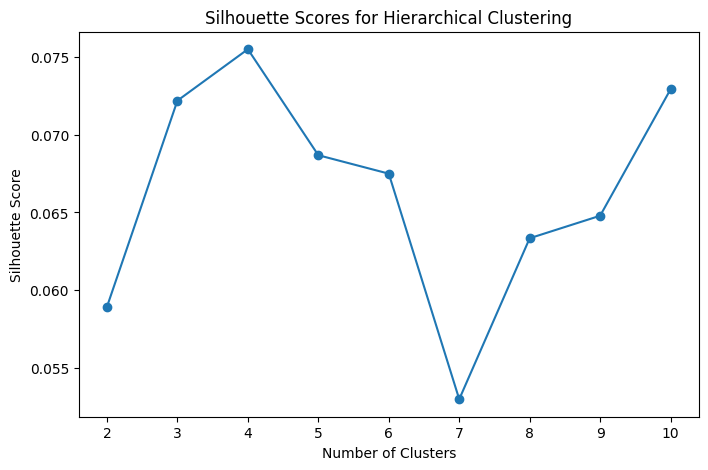

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    hierarchical_silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Hierarchical Clustering")
plt.xticks(range(2, 11))
plt.show()

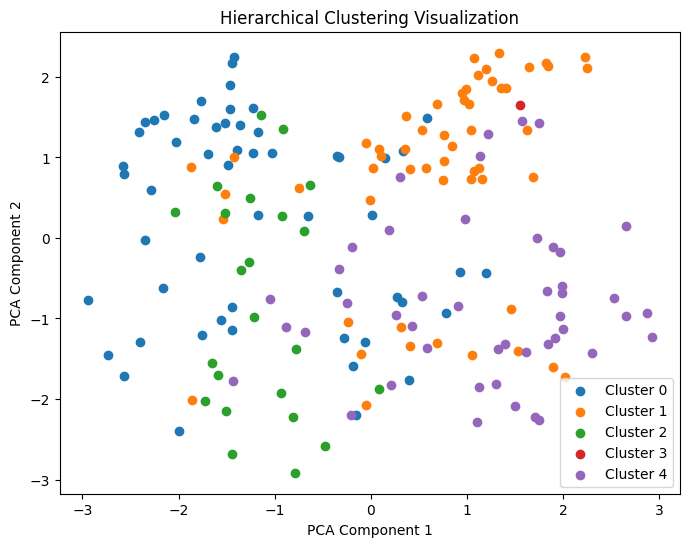

In [93]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

hierarchical_pca_df = pd.DataFrame({
    "PCA_1": X_pca[:, 0],
    "PCA_2": X_pca[:, 1],
    "Hierarchical_Cluster": hierarchical_labels
})

plt.figure(figsize=(8, 6))

for cluster in sorted(hierarchical_pca_df["Hierarchical_Cluster"].unique()):
    cluster_data = hierarchical_pca_df[
        hierarchical_pca_df["Hierarchical_Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PCA_1"],
        cluster_data["PCA_2"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Hierarchical Clustering Visualization")
plt.legend()
plt.show()

In [94]:
numerical_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

hierarchical_summary = df.groupby(
    "Hierarchical_Cluster"
)[numerical_columns].mean().round(2)

hierarchical_summary

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Hierarchical_Cluster,,,,,,,
0,36.62,67050.91,37.82,73.84,2.78,16.01,5.71
1,35.49,68003.64,40.24,76.02,3.18,19.04,6.02
2,33.52,64013.04,37.43,75.09,3.09,16.64,5.96
3,31.00,107100.00,38.00,55.24,2.00,20.60,9.00
4,38.43,59271.74,38.28,75.33,3.24,22.37,5.35


In [95]:
categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

for column in categorical_columns:
    print("\n", column, "by Hierarchical Cluster")

    print(
        pd.crosstab(
            df["Hierarchical_Cluster"],
            df[column],
            normalize="index"
        ).round(2)
    )


 Contract_Type by Hierarchical Cluster
Contract_Type         1 Year  2 Year  Monthly
Hierarchical_Cluster                         
0                       0.65    0.02     0.33
1                       0.09    0.02     0.89
2                       0.04    0.96     0.00
3                       0.00    0.00     1.00
4                       0.22    0.00     0.78

 Payment_Method by Hierarchical Cluster
Payment_Method        Bank Transfer  Credit Card  Debit Card   UPI  Unknown
Hierarchical_Cluster                                                       
0                              0.27         0.18        0.27  0.27      0.0
1                              0.22         0.45        0.00  0.33      0.0
2                              0.17         0.09        0.39  0.35      0.0
3                              0.00         0.00        0.00  0.00      1.0
4                              0.35         0.15        0.37  0.13      0.0

 Region by Hierarchical Cluster
Region                East  Nort

### DBSCAN

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [97]:
print("Shape of scaled data:", X_scaled.shape)
print("Number of customer records:", X_scaled.shape[0])
print("Number of features:", X_scaled.shape[1])

Shape of scaled data: (180, 22)
Number of customer records: 180
Number of features: 22


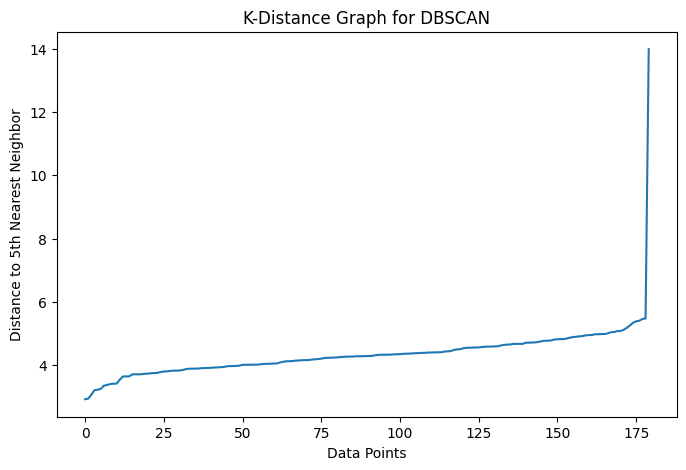

In [98]:
neighbors = NearestNeighbors(n_neighbors=5)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

distances = sorted(distances[:, 4])

plt.figure(figsize=(8, 5))
plt.plot(distances)

plt.xlabel("Data Points")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.title("K-Distance Graph for DBSCAN")
plt.show()

In [99]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN clustering completed.")

DBSCAN clustering completed.


In [100]:
print("Number of customers in each cluster:")

print(
    df["DBSCAN_Cluster"]
    .value_counts()
    .sort_index()
)

number_of_clusters = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)

number_of_noise = list(dbscan_labels).count(-1)

print("\nNumber of clusters:", number_of_clusters)
print("Number of noise points:", number_of_noise)

Number of customers in each cluster:
DBSCAN_Cluster
-1    180
Name: count, dtype: int64

Number of clusters: 0
Number of noise points: 180


In [101]:
non_noise = dbscan_labels != -1

unique_clusters = set(dbscan_labels[non_noise])

if len(unique_clusters) >= 2:
    score = silhouette_score(
        X_scaled[non_noise],
        dbscan_labels[non_noise]
    )

    print("Silhouette Score:", round(score, 4))

else:
    print(
        "Silhouette Score cannot be calculated: "
        "fewer than 2 non-noise clusters were found."
    )

Silhouette Score cannot be calculated: fewer than 2 non-noise clusters were found.


In [102]:
eps_values = [0.3, 0.5, 0.7, 1.0]

for eps_value in eps_values:
    model = DBSCAN(
        eps=eps_value,
        min_samples=5
    )

    labels = model.fit_predict(X_scaled)

    clusters = len(set(labels)) - (
        1 if -1 in labels else 0
    )

    noise = list(labels).count(-1)

    print(
        "eps =", eps_value,
        "| Clusters =", clusters,
        "| Noise Points =", noise
    )

eps = 0.3 | Clusters = 0 | Noise Points = 180
eps = 0.5 | Clusters = 0 | Noise Points = 180
eps = 0.7 | Clusters = 0 | Noise Points = 180
eps = 1.0 | Clusters = 0 | Noise Points = 180


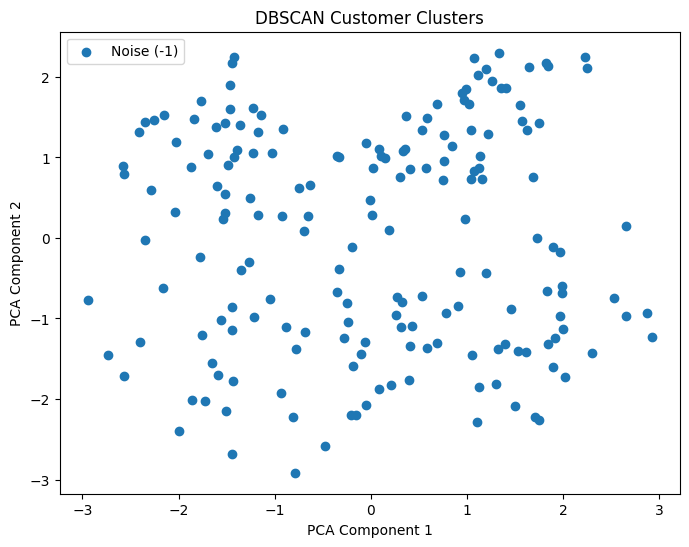

In [103]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

dbscan_pca_df = pd.DataFrame({
    "PCA_1": X_pca[:, 0],
    "PCA_2": X_pca[:, 1],
    "DBSCAN_Cluster": dbscan_labels
})

plt.figure(figsize=(8, 6))

for cluster in sorted(dbscan_pca_df["DBSCAN_Cluster"].unique()):
    cluster_data = dbscan_pca_df[
        dbscan_pca_df["DBSCAN_Cluster"] == cluster
    ]

    label_name = (
        "Noise (-1)" if cluster == -1
        else f"Cluster {cluster}"
    )

    plt.scatter(
        cluster_data["PCA_1"],
        cluster_data["PCA_2"],
        label=label_name
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("DBSCAN Customer Clusters")
plt.legend()
plt.show()

In [104]:
numerical_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

dbscan_summary = df.groupby(
    "DBSCAN_Cluster"
)[numerical_columns].mean().round(2)

dbscan_summary

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
DBSCAN_Cluster,,,,,,,
-1,36.31,65188.33,38.63,74.94,3.06,18.67,5.76


In [105]:
categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

for column in categorical_columns:
    print("\n", column, "by DBSCAN Cluster")

    print(
        pd.crosstab(
            df["DBSCAN_Cluster"],
            df[column],
            normalize="index"
        ).round(2)
    )


 Contract_Type by DBSCAN Cluster
Contract_Type   1 Year  2 Year  Monthly
DBSCAN_Cluster                         
-1                0.29    0.13     0.58

 Payment_Method by DBSCAN Cluster
Payment_Method  Bank Transfer  Credit Card  Debit Card   UPI  Unknown
DBSCAN_Cluster                                                       
-1                       0.26         0.24        0.23  0.26     0.01

 Region by DBSCAN Cluster
Region          East  North  South  West
DBSCAN_Cluster                          
-1              0.19   0.28   0.28  0.26

 Plan_Type by DBSCAN Cluster
Plan_Type       Basic  Premium  Standard
DBSCAN_Cluster                          
-1               0.26     0.22      0.52


### PCA — Principal Component Analysis

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

In [107]:
print("Original data shape:", X_scaled.shape)
print("Number of customer records:", X_scaled.shape[0])
print("Number of original features:", X_scaled.shape[1])

Original data shape: (180, 22)
Number of customer records: 180
Number of original features: 22


In [108]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Data shape after PCA:", X_pca.shape)

Data shape after PCA: (180, 2)


In [109]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total variance retained:",
    round(sum(pca.explained_variance_ratio_) * 100, 2),
    "%"
)

Explained variance ratio:
[0.09289402 0.08624705]
Total variance retained: 17.91 %


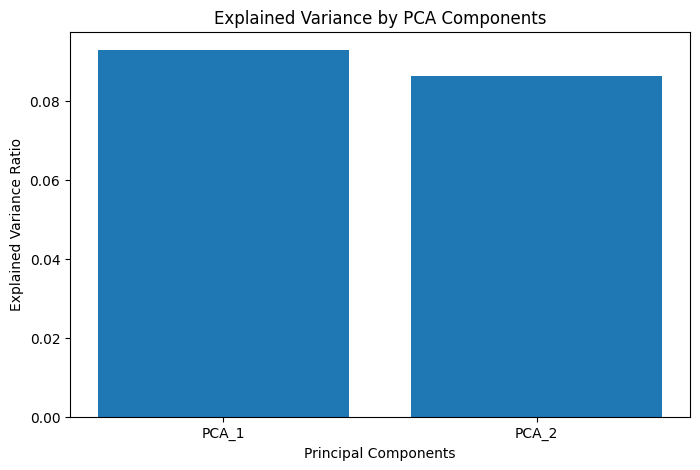

In [110]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["PCA_1", "PCA_2"],
    pca.explained_variance_ratio_
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by PCA Components")
plt.show()

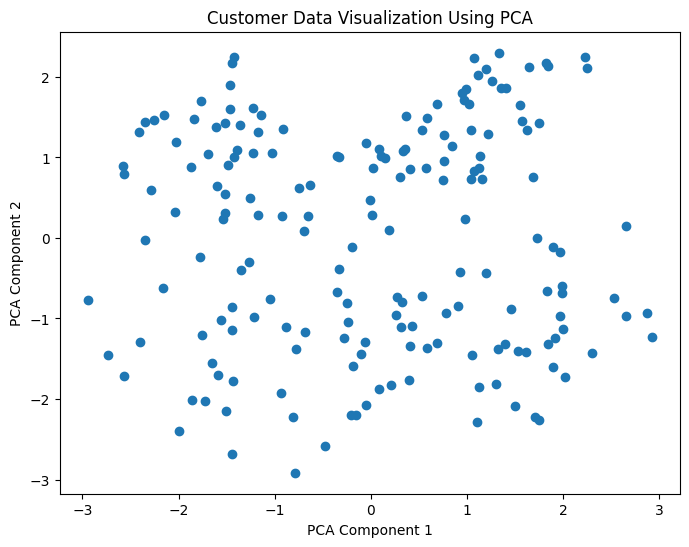

In [111]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PCA_1", "PCA_2"]
)

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PCA_1"],
    pca_df["PCA_2"]
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Data Visualization Using PCA")
plt.show()

In [112]:
pca_95 = PCA(n_components=0.95)

X_pca_95 = pca_95.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Features after PCA:", X_pca_95.shape[1])

print(
    "Variance retained:",
    round(sum(pca_95.explained_variance_ratio_) * 100, 2),
    "%"
)

Original number of features: 22
Features after PCA: 17
Variance retained: 97.18 %


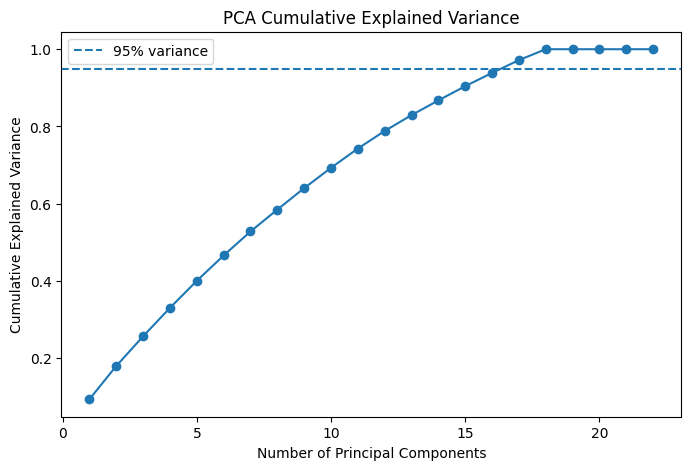

In [113]:
pca_full = PCA()

pca_full.fit(X_scaled)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.show()

### Apriori Algorithm

In [114]:
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules

In [115]:
%pip install mlxtend

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [116]:
categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

numerical_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

apriori_df = df[
    categorical_columns + numerical_columns
].copy()

apriori_df.head()

,Contract_Type,Payment_Method,Region,Plan_Type,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
0,Monthly,Bank Transfer,North,Standard,22.0,23800.0,11.0,62.96,7.0,20.4,5.0
1,Monthly,Bank Transfer,South,Basic,35.0,69400.0,17.0,75.63,6.0,17.5,9.0
2,Monthly,UPI,West,Basic,55.0,64700.0,49.0,92.85,3.0,21.6,1.0
3,Monthly,UPI,South,Standard,36.0,80000.0,9.0,85.67,0.0,34.3,9.0
4,Monthly,Debit Card,West,Premium,41.0,95700.0,51.0,60.77,1.0,23.7,9.0


In [117]:
for column in numerical_columns:
    apriori_df[column] = pd.qcut(
        apriori_df[column],
        q=3,
        labels=["Low", "Medium", "High"],
        duplicates="drop"
    )

apriori_df.head()

,Contract_Type,Payment_Method,Region,Plan_Type,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
0,Monthly,Bank Transfer,North,Standard,Low,Low,Low,Low,High,Medium,Medium
1,Monthly,Bank Transfer,South,Basic,Medium,Medium,Low,Medium,High,Medium,High
2,Monthly,UPI,West,Basic,High,Medium,Medium,High,Medium,Medium,Low
3,Monthly,UPI,South,Standard,Medium,High,Low,High,Low,High,High
4,Monthly,Debit Card,West,Premium,High,High,High,Low,Low,High,High


In [118]:
transaction_data = pd.get_dummies(
    apriori_df,
    dtype=bool
)

print("Transaction data shape:", transaction_data.shape)

transaction_data.head()

Transaction data shape: (180, 36)


,Contract_Type_1 Year,Contract_Type_2 Year,Contract_Type_Monthly,Payment_Method_Bank Transfer,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_UPI,Payment_Method_Unknown,Region_East,Region_North,...,Monthly_Charges_High,Support_Calls_Last_3M_Low,Support_Calls_Last_3M_Medium,Support_Calls_Last_3M_High,Data_Usage_GB_Low,Data_Usage_GB_Medium,Data_Usage_GB_High,Satisfaction_Score_Low,Satisfaction_Score_Medium,Satisfaction_Score_High
0,False,False,True,True,False,False,False,False,False,True,...,False,False,False,True,False,True,False,False,True,False
1,False,False,True,True,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,True
2,False,False,True,False,False,False,True,False,False,False,...,True,False,True,False,False,True,False,True,False,False
3,False,False,True,False,False,False,True,False,False,False,...,True,True,False,False,False,False,True,False,False,True
4,False,False,True,False,False,True,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True


In [119]:
frequent_itemsets = apriori(
    transaction_data,
    min_support=0.10,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

frequent_itemsets

,support,itemsets
2,0.577778,frozenset({Contract_Type_Monthly})
13,0.522222,frozenset({Plan_Type_Standard})
27,0.461111,frozenset({Support_Calls_Last_3M_Medium})
26,0.361111,frozenset({Support_Calls_Last_3M_Low})
14,0.355556,frozenset({Age_Low})
...,...,...
39,0.100000,"frozenset({Monthly_Charges_Low, Contract_Type_..."
42,0.100000,"frozenset({Data_Usage_GB_Low, Contract_Type_1 ..."
43,0.100000,"frozenset({Data_Usage_GB_Medium, Contract_Type..."
300,0.100000,"frozenset({Data_Usage_GB_High, Satisfaction_Sc..."


In [120]:
frequent_itemsets = apriori(
    transaction_data,
    min_support=0.10,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

frequent_itemsets

,support,itemsets
2,0.577778,frozenset({Contract_Type_Monthly})
13,0.522222,frozenset({Plan_Type_Standard})
27,0.461111,frozenset({Support_Calls_Last_3M_Medium})
26,0.361111,frozenset({Support_Calls_Last_3M_Low})
14,0.355556,frozenset({Age_Low})
...,...,...
39,0.100000,"frozenset({Monthly_Charges_Low, Contract_Type_..."
42,0.100000,"frozenset({Data_Usage_GB_Low, Contract_Type_1 ..."
43,0.100000,"frozenset({Data_Usage_GB_Medium, Contract_Type..."
300,0.100000,"frozenset({Data_Usage_GB_High, Satisfaction_Sc..."


In [121]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.50
)

rules = rules.sort_values(
    by="lift",
    ascending=False
)

rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]]

,antecedents,consequents,support,confidence,lift
90,frozenset({Support_Calls_Last_3M_High}),frozenset({Satisfaction_Score_Medium}),0.105556,0.593750,1.752049
57,frozenset({Payment_Method_Debit Card}),frozenset({Tenure_Months_High}),0.127778,0.560976,1.740959
79,frozenset({Plan_Type_Premium}),frozenset({Data_Usage_GB_Low}),0.111111,0.512821,1.538462
60,frozenset({Payment_Method_Credit Card}),frozenset({Annual_Income_Medium}),0.122222,0.500000,1.500000
96,"frozenset({Data_Usage_GB_Low, Contract_Type_Mo...",frozenset({Support_Calls_Last_3M_Low}),0.100000,0.529412,1.466063
...,...,...,...,...,...
54,"frozenset({Plan_Type_Standard, Support_Calls_L...",frozenset({Contract_Type_Monthly}),0.133333,0.521739,0.903010
102,"frozenset({Plan_Type_Standard, Age_Low})",frozenset({Contract_Type_Monthly}),0.100000,0.514286,0.890110
77,"frozenset({Plan_Type_Standard, Data_Usage_GB_M...",frozenset({Contract_Type_Monthly}),0.111111,0.512821,0.887574
72,frozenset({Payment_Method_Debit Card}),frozenset({Contract_Type_Monthly}),0.116667,0.512195,0.886492


In [122]:
strong_rules = rules[
    (rules["confidence"] >= 0.60) &
    (rules["lift"] > 1)
]

strong_rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]]

,antecedents,consequents,support,confidence,lift
68,"frozenset({Plan_Type_Standard, Satisfaction_Sc...",frozenset({Support_Calls_Last_3M_Medium}),0.116667,0.636364,1.380066
86,"frozenset({Plan_Type_Standard, Tenure_Months_L...",frozenset({Support_Calls_Last_3M_Medium}),0.105556,0.633333,1.373494
61,"frozenset({Plan_Type_Standard, Age_Medium})",frozenset({Support_Calls_Last_3M_Medium}),0.122222,0.611111,1.325301
81,"frozenset({Monthly_Charges_Medium, Support_Cal...",frozenset({Plan_Type_Standard}),0.105556,0.655172,1.254585
95,"frozenset({Support_Calls_Last_3M_Low, Data_Usa...",frozenset({Contract_Type_Monthly}),0.100000,0.720000,1.246154
62,"frozenset({Age_Medium, Support_Calls_Last_3M_M...",frozenset({Plan_Type_Standard}),0.122222,0.647059,1.239049
69,"frozenset({Support_Calls_Last_3M_Medium, Satis...",frozenset({Plan_Type_Standard}),0.116667,0.636364,1.218569
71,"frozenset({Data_Usage_GB_Medium, Support_Calls...",frozenset({Plan_Type_Standard}),0.116667,0.636364,1.218569
76,"frozenset({Monthly_Charges_Medium, Support_Cal...",frozenset({Contract_Type_Monthly}),0.111111,0.689655,1.193634
100,"frozenset({Support_Calls_Last_3M_Medium, Annua...",frozenset({Plan_Type_Standard}),0.100000,0.620690,1.188555


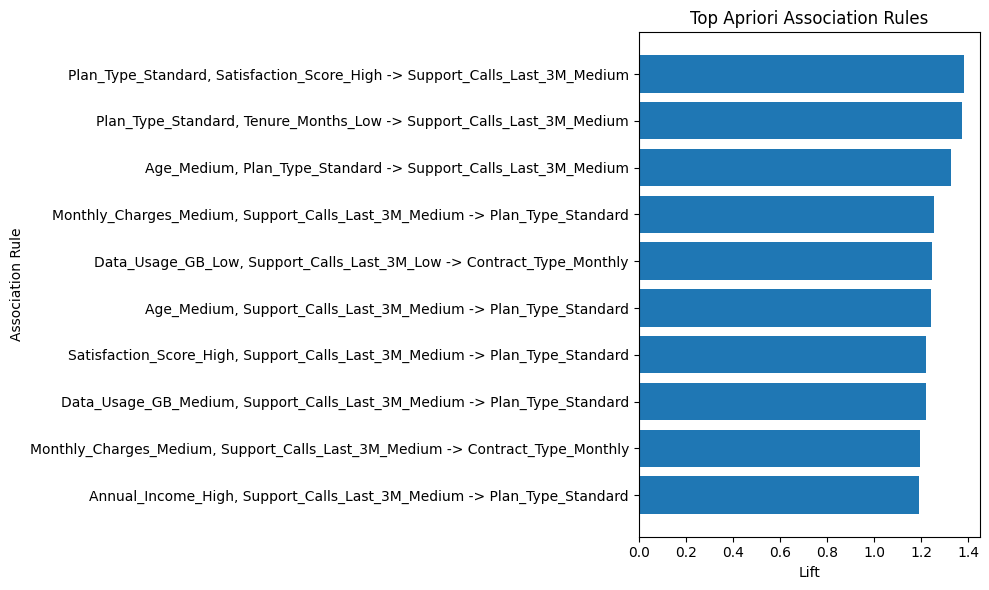

In [123]:
if not strong_rules.empty:
    top_rules = strong_rules.head(10).copy()

    top_rules["Rule"] = top_rules.apply(
        lambda row:
        f"{', '.join(sorted(row['antecedents']))} -> "
        f"{', '.join(sorted(row['consequents']))}",
        axis=1
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_rules["Rule"],
        top_rules["lift"]
    )

    plt.xlabel("Lift")
    plt.ylabel("Association Rule")
    plt.title("Top Apriori Association Rules")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

else:
    print("No strong rules found with the current thresholds.")